In [28]:
# 1. Define start and end dates
start_date = '2000-01-01'
end_date = '2023-12-31'

# 2. Generate a series of dates
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# 3. Create synthetic 'temperature' data (15 to 45 degrees Celsius)
temperature = np.random.uniform(low=15, high=45, size=len(dates))

# 4. Create synthetic 'humidity' data (30 to 100 percent)
humidity = np.random.uniform(low=30, high=100, size=len(dates))

# 5. Create synthetic 'precipitation' data (0 to 50 mm, with many zeros)
# Introduce a high probability of zero precipitation (e.g., 70% chance of no rain)
precipitation = np.where(np.random.rand(len(dates)) < 0.7, 0, np.random.uniform(low=0.1, high=50, size=len(dates)))

# 6. Combine into a Pandas DataFrame
weather_df = pd.DataFrame({
    'Date': dates,
    'Temperature_Celsius': temperature,
    'Humidity_Percent': humidity,
    'Precipitation_mm': precipitation
})

# 7. Save the DataFrame to a CSV file
weather_df.to_csv('weather_data.csv', index=False)

print("Synthetic weather_data.csv created successfully with shape:", weather_df.shape)

Synthetic weather_data.csv created successfully with shape: (8766, 4)


## Generate Dataset



In [29]:
import pandas as pd
import numpy as np

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load and Inspect Data




In [31]:
weather_df = pd.read_csv('weather_data.csv')

print("First 5 rows of the DataFrame:")
print(weather_df.head())

print("\nData types of each column:")
print(weather_df.info())

print("\nSummary statistics for numerical columns:")
print(weather_df.describe())

First 5 rows of the DataFrame:
         Date  Temperature_Celsius  Humidity_Percent  Precipitation_mm
0  2000-01-01            30.274780         77.182345               0.0
1  2000-01-02            25.316768         47.806835               0.0
2  2000-01-03            39.792365         67.244404               0.0
3  2000-01-04            20.760341         99.794150               0.0
4  2000-01-05            34.305818         82.915707               0.0

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 0 to 8765
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 8766 non-null   object 
 1   Temperature_Celsius  8766 non-null   float64
 2   Humidity_Percent     8766 non-null   float64
 3   Precipitation_mm     8766 non-null   float64
dtypes: float64(3), object(1)
memory usage: 274.1+ KB
None

Summary statistics for numerical columns:
       

## Data Cleaning

###
Handle missing values in the dataset and convert the 'date' column to datetime format.


In [32]:
print("Missing values before cleaning:")
print(weather_df.isnull().sum())

# Convert 'Date' column to datetime format
weather_df['Date'] = pd.to_datetime(weather_df['Date'])

print("\n'Date' column converted to datetime format.")
print("Data types after conversion:")
print(weather_df.info())

Missing values before cleaning:
Date                   0
Temperature_Celsius    0
Humidity_Percent       0
Precipitation_mm       0
dtype: int64

'Date' column converted to datetime format.
Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 0 to 8765
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 8766 non-null   datetime64[ns]
 1   Temperature_Celsius  8766 non-null   float64       
 2   Humidity_Percent     8766 non-null   float64       
 3   Precipitation_mm     8766 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 274.1 KB
None


## Descriptive Statistics

###
Calculate mean, median, and standard deviation for temperature, humidity, and precipitation using NumPy.


In [33]:
import numpy as np

# 1. Calculate statistics for 'Temperature_Celsius'
temperature_data = weather_df['Temperature_Celsius'].to_numpy()
temp_mean = np.mean(temperature_data)
temp_median = np.median(temperature_data)
temp_std = np.std(temperature_data)
print(f"--- Temperature Statistics ---")
print(f"Mean Temperature: {temp_mean:.2f} Celsius")
print(f"Median Temperature: {temp_median:.2f} Celsius")
print(f"Standard Deviation Temperature: {temp_std:.2f} Celsius\n")

# 2. Calculate statistics for 'Humidity_Percent'
humidity_data = weather_df['Humidity_Percent'].to_numpy()
hum_mean = np.mean(humidity_data)
hum_median = np.median(humidity_data)
hum_std = np.std(humidity_data)
print(f"--- Humidity Statistics ---")
print(f"Mean Humidity: {hum_mean:.2f} Percent")
print(f"Median Humidity: {hum_median:.2f} Percent")
print(f"Standard Deviation Humidity: {hum_std:.2f} Percent\n")

# 3. Calculate statistics for 'Precipitation_mm'
precipitation_data = weather_df['Precipitation_mm'].to_numpy()
prec_mean = np.mean(precipitation_data)
prec_median = np.median(precipitation_data)
prec_std = np.std(precipitation_data)
print(f"--- Precipitation Statistics ---")
print(f"Mean Precipitation: {prec_mean:.2f} mm")
print(f"Median Precipitation: {prec_median:.2f} mm")
print(f"Standard Deviation Precipitation: {prec_std:.2f} mm")

--- Temperature Statistics ---
Mean Temperature: 29.99 Celsius
Median Temperature: 30.06 Celsius
Standard Deviation Temperature: 8.69 Celsius

--- Humidity Statistics ---
Mean Humidity: 64.96 Percent
Median Humidity: 65.14 Percent
Standard Deviation Humidity: 20.30 Percent

--- Precipitation Statistics ---
Mean Precipitation: 7.54 mm
Median Precipitation: 0.00 mm
Standard Deviation Precipitation: 13.88 mm


## Monthly and Seasonal Analysis

###
Group the data by month or season using Pandas and analyze average values of key metrics like temperature, humidity, and precipitation.


In [34]:
import pandas as pd

# 1. Extract the month number from the 'Date' column
weather_df['Month'] = weather_df['Date'].dt.month

# 2. Create a new column named 'Season'
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Monsoon/Summer'
    else:
        return 'Autumn'

weather_df['Season'] = weather_df['Month'].apply(get_season)

# 3. Group by 'Month' and calculate mean statistics
monthly_avg = weather_df.groupby('Month')[['Temperature_Celsius', 'Humidity_Percent', 'Precipitation_mm']].mean()
print("\n--- Monthly Average Statistics ---")
print(monthly_avg)

# 4. Group by 'Season' and calculate mean statistics
seasonal_avg = weather_df.groupby('Season')[['Temperature_Celsius', 'Humidity_Percent', 'Precipitation_mm']].mean()
# Reorder seasons for better readability
season_order = ['Winter', 'Spring', 'Monsoon/Summer', 'Autumn']
seasonal_avg = seasonal_avg.reindex(season_order)
print("\n--- Seasonal Average Statistics ---")
print(seasonal_avg)

print("\nMonthly and seasonal analysis completed.")


--- Monthly Average Statistics ---
       Temperature_Celsius  Humidity_Percent  Precipitation_mm
Month                                                         
1                30.089399         65.478887          7.329380
2                30.081511         64.674639          7.289389
3                29.607403         65.481476          7.151153
4                30.408124         64.084397          8.993352
5                29.754226         65.781505          7.560248
6                30.504554         63.915451          7.548860
7                29.748634         65.315096          7.421881
8                29.506942         65.065051          7.836025
9                29.842266         65.096359          6.990462
10               30.051311         64.729484          7.697212
11               29.840053         65.855224          7.420568
12               30.449354         63.985522          7.228001

--- Seasonal Average Statistics ---
                Temperature_Celsius  Humidity

## Visualizations

###
Generate visualizations using Matplotlib: a line plot for average temperature trends, a bar plot for average precipitation by month, and a histogram for temperature distribution.


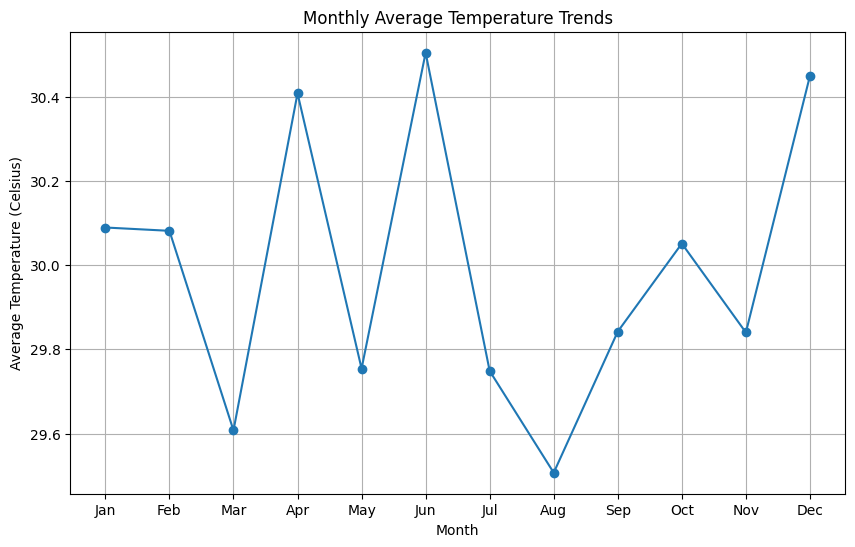

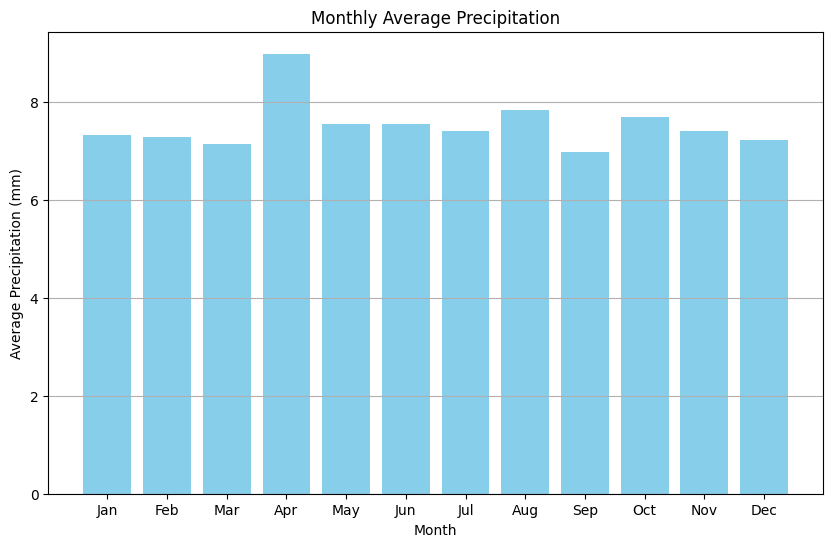

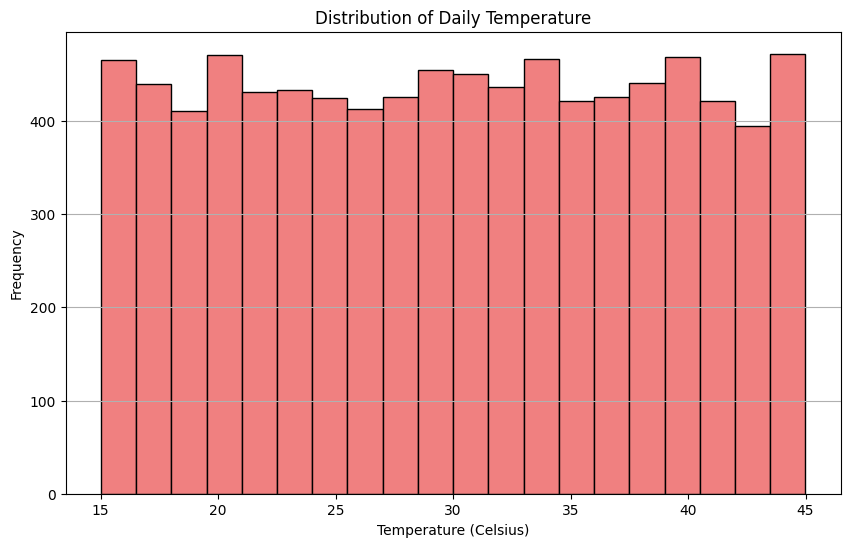

Visualizations generated successfully.


In [35]:
import matplotlib.pyplot as plt

# 1. Line plot for Monthly Average Temperature Trends
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg['Temperature_Celsius'], marker='o', linestyle='-')
plt.title('Monthly Average Temperature Trends')
plt.xlabel('Month')
plt.ylabel('Average Temperature (Celsius)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

# 2. Bar plot for Monthly Average Precipitation
plt.figure(figsize=(10, 6))
plt.bar(monthly_avg.index, monthly_avg['Precipitation_mm'], color='skyblue')
plt.title('Monthly Average Precipitation')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y')
plt.show()

# 3. Histogram for Daily Temperature Distribution
plt.figure(figsize=(10, 6))
plt.hist(weather_df['Temperature_Celsius'], bins=20, edgecolor='black', color='lightcoral')
plt.title('Distribution of Daily Temperature')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

print("Visualizations generated successfully.")


**Identify Extreme Weather**

## Calculate Extreme Value Thresholds

###
Calculate statistical thresholds for extreme high and low temperatures, and extreme high precipitation using the mean and standard deviation.


In [36]:
import numpy as np

# 1. Define a standard deviation multiplier
std_multiplier = 2  # A common choice for identifying 'extreme' values

# 2. Calculate the high_temp_threshold
high_temp_threshold = temp_mean + (std_multiplier * temp_std)

# 3. Calculate the low_temp_threshold
low_temp_threshold = temp_mean - (std_multiplier * temp_std)

# 4. Calculate the high_prec_threshold
high_prec_threshold = prec_mean + (std_multiplier * prec_std)

# 5. Print the calculated thresholds
print(f"--- Extreme Value Thresholds (with {std_multiplier}x Standard Deviation) ---")
print(f"High Temperature Threshold: {high_temp_threshold:.2f} Celsius")
print(f"Low Temperature Threshold: {low_temp_threshold:.2f} Celsius")
print(f"High Precipitation Threshold: {high_prec_threshold:.2f} mm")

--- Extreme Value Thresholds (with 2x Standard Deviation) ---
High Temperature Threshold: 47.36 Celsius
Low Temperature Threshold: 12.61 Celsius
High Precipitation Threshold: 35.31 mm


In [37]:
import pandas as pd

# 1. Identify extreme high temperature days
extreme_high_temp_days = weather_df[weather_df['Temperature_Celsius'] > high_temp_threshold]

# 2. Identify extreme low temperature days
extreme_low_temp_days = weather_df[weather_df['Temperature_Celsius'] < low_temp_threshold]

# 3. Identify extreme high precipitation days
extreme_prec_days = weather_df[weather_df['Precipitation_mm'] > high_prec_threshold]

print(f"Number of extreme high temperature days: {len(extreme_high_temp_days)}")
print(f"Number of extreme low temperature days: {len(extreme_low_temp_days)}")
print(f"Number of extreme high precipitation days: {len(extreme_prec_days)}")

print("\nFirst 5 extreme high temperature days:")
print(extreme_high_temp_days.head())

print("\nFirst 5 extreme low temperature days:")
print(extreme_low_temp_days.head())

print("\nFirst 5 extreme high precipitation days:")
print(extreme_prec_days.head())

Number of extreme high temperature days: 0
Number of extreme low temperature days: 0
Number of extreme high precipitation days: 778

First 5 extreme high temperature days:
Empty DataFrame
Columns: [Date, Temperature_Celsius, Humidity_Percent, Precipitation_mm, Month, Season]
Index: []

First 5 extreme low temperature days:
Empty DataFrame
Columns: [Date, Temperature_Celsius, Humidity_Percent, Precipitation_mm, Month, Season]
Index: []

First 5 extreme high precipitation days:
          Date  Temperature_Celsius  Humidity_Percent  Precipitation_mm  \
50  2000-02-20            35.712868         60.736103         37.121982   
64  2000-03-05            30.670812         35.294862         45.437184   
91  2000-04-01            36.536298         98.302082         36.374622   
96  2000-04-06            34.102359         88.511392         39.028794   
104 2000-04-14            21.179861         78.064980         36.439223   

     Month  Season  
50       2  Winter  
64       3  Spring  
91   

## Visualize Extreme Events

###
Generate visualizations to highlight the identified extreme temperature and precipitation events within the dataset.


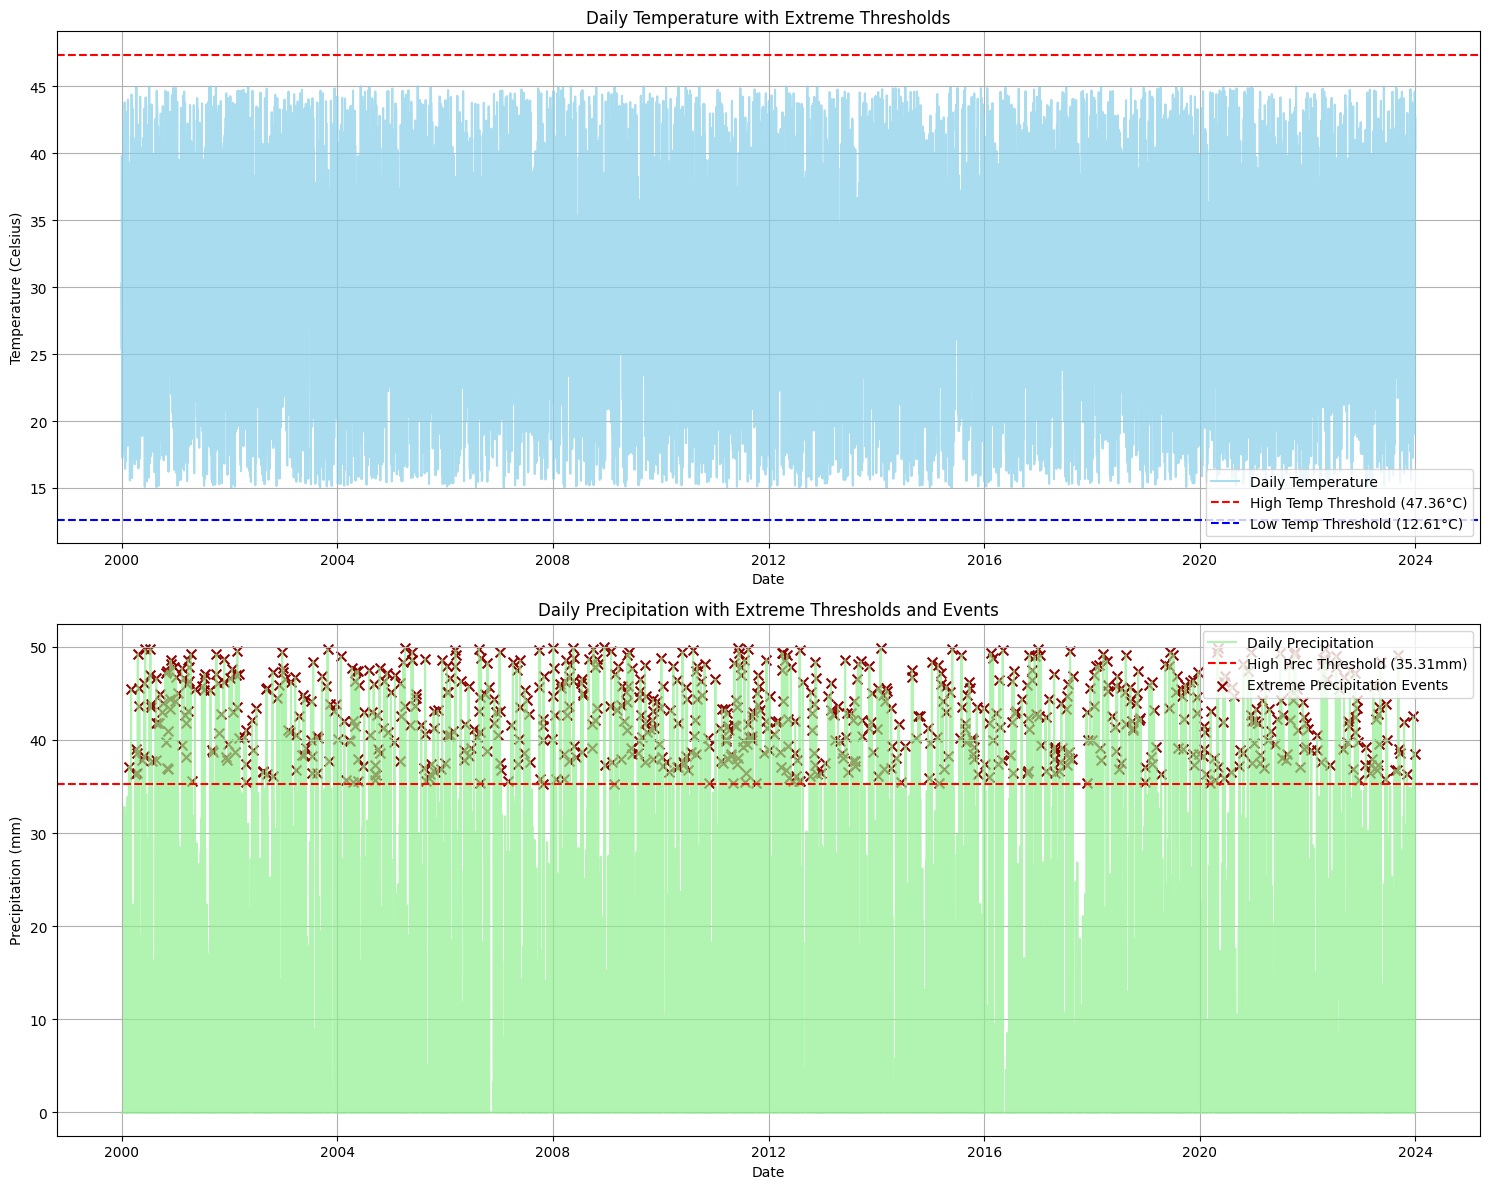

Visualizations for extreme events generated successfully.


In [38]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# --- First Subplot: Temperature ---
# Plot daily temperature
axes[0].plot(weather_df['Date'], weather_df['Temperature_Celsius'], label='Daily Temperature', color='skyblue', alpha=0.7)
# Add high temperature threshold
axes[0].axhline(y=high_temp_threshold, color='red', linestyle='--', label=f'High Temp Threshold ({high_temp_threshold:.2f}°C)')
# Add low temperature threshold
axes[0].axhline(y=low_temp_threshold, color='blue', linestyle='--', label=f'Low Temp Threshold ({low_temp_threshold:.2f}°C)')

axes[0].set_title('Daily Temperature with Extreme Thresholds')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Temperature (Celsius)')
axes[0].legend()
axes[0].grid(True)

# --- Second Subplot: Precipitation ---
# Plot daily precipitation
axes[1].plot(weather_df['Date'], weather_df['Precipitation_mm'], label='Daily Precipitation', color='lightgreen', alpha=0.7)
# Add high precipitation threshold
axes[1].axhline(y=high_prec_threshold, color='red', linestyle='--', label=f'High Prec Threshold ({high_prec_threshold:.2f}mm)')
# Plot extreme precipitation days
axes[1].scatter(extreme_prec_days['Date'], extreme_prec_days['Precipitation_mm'], color='darkred', marker='x', s=50, label='Extreme Precipitation Events')

axes[1].set_title('Daily Precipitation with Extreme Thresholds and Events')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()
axes[1].grid(True)

# Ensure plots do not overlap
plt.tight_layout()

# Display the plots
plt.show()

print("Visualizations for extreme events generated successfully.")